### SARIMA Model

<class 'pandas.Series'>
DatetimeIndex: 1255 entries, 2023-01-01 to 2026-06-08
Freq: D
Series name: actual_ail
Non-Null Count  Dtype
--------------  -----
1255 non-null   int64
dtypes: int64(1)
memory usage: 19.6 KB
None
gaps created: 0


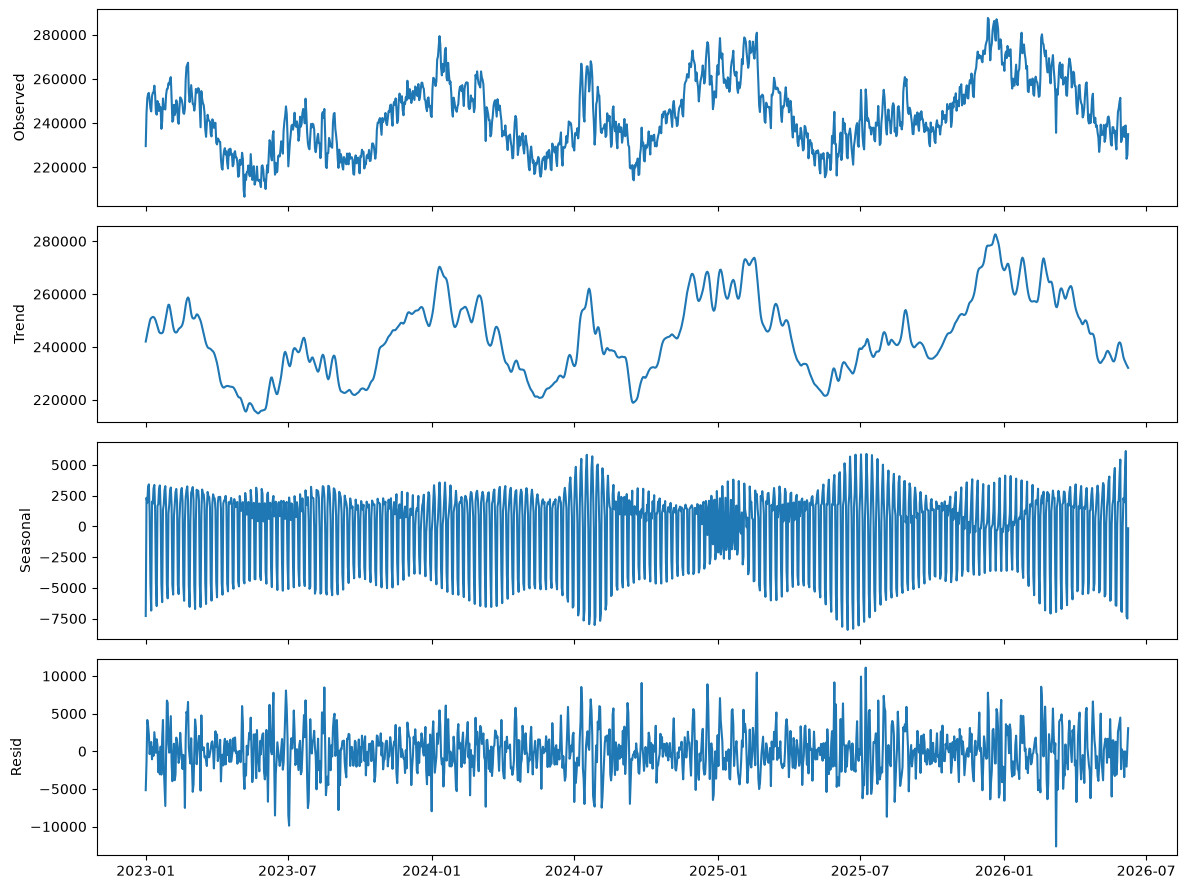

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pmdarima as pm
from pmdarima.model_selection import RollingForecastCV, cross_val_score
import itertools
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
################### Load Data #####################################
AIL = pd.read_csv('data/ActualForecastData.csv', parse_dates=['date_he'])
AIL_indexed = AIL.set_index('date_he')
daily_sum = AIL_indexed['actual_ail'].resample('D').sum()
daily_count = AIL_indexed['actual_ail'].resample('D').count()

# Create time series.
# Keep only days with full observations (handles DST: 23 or 25 hours)
full_day = daily_count.mode()[0]
demand_data = daily_sum[(daily_count >= full_day - 1) & (daily_count <= full_day + 1)]
demand_data = demand_data.asfreq('D')
print(demand_data.info())
print("gaps created:", demand_data.isna().sum())
demand_data = demand_data.interpolate()

result = STL(demand_data, period=7, seasonal=13).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(result.observed); axes[0].set_ylabel('Observed')
axes[1].plot(result.trend);    axes[1].set_ylabel('Trend')
axes[2].plot(result.seasonal); axes[2].set_ylabel('Seasonal')
axes[3].plot(result.resid);    axes[3].set_ylabel('Resid')
plt.tight_layout(); plt.show()


#### Stationary Check (ADF test)
ADF tests the null hypothesis that there is the existence of a unit root in the time series sample.
The presence of a unit root implies that the time series is non-stationary, that is,
its statistical properties such as mean and variance change over time and the series
follows a stochastic trend rather than reverting to a fixed mean.

In [25]:
def adftest(dataset):
    try:
        result = adfuller(dataset, autolag='AIC')
        print(f'ADF Statistic: {result[0]:.4f}')
        print(f'p-value: {result[1]:.4f}')
        print(f'Lags used: {result[2]}')
        print(f'Critical values: {result[4]}')
        if result[1] < 0.05:
            print('Time Series is Stationary')
        else:
            print('Fail to reject null hypothesis. Time Series is Non-Stationary')
    except Exception as e:
        print(f'Invalid dataset: {e}')

adftest(demand_data)

ADF Statistic: -2.7364
p-value: 0.0679
Lags used: 21
Critical values: {'1%': np.float64(-3.4356646522289815), '5%': np.float64(-2.863886926389418), '10%': np.float64(-2.568019536239491)}
Fail to reject null hypothesis. Time Series is Non-Stationary


#### Differencing
Differencing is a method used to transform a non-stationary time series by calculating
the difference between consecutive observations.

$$y'_t = y_t - y_{t-1}$$

It stabilizes the mean of a time series by removing changes in level and trend,
making it more suitable for modelling.

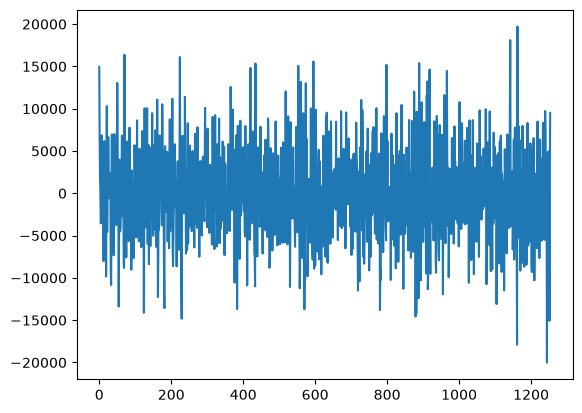

In [26]:
def adftest(dataset):
    try:
        result = adfuller(dataset, autolag='AIC')
        return result[1] < 0.05  # return True if stationary
    except Exception as e:
        print(f'Invalid dataset: {e}')
        return None

def difference(dataset, interval=1):
    if adftest(dataset):  # if stationary, skip
        print('Time Series is already stationary, no differencing needed')
        return dataset
    diff = []
    for i in range(interval, len(dataset)):
        diff.append(dataset.iloc[i] - dataset.iloc[i - interval])
    return pd.Series(diff)

difference(demand_data).plot()
plt.show()

#### Model Parameters
**Autocorrelation function (ACF):** Measures the correlation between the past values (lagged values) and the current value, including indirect effects. We will use the ACF to find Moving Average parameter q.

**Partial Autocorrelation function (PACF):** Measures the direct correlation between the k-th lagged value and the current value, removing indirect effects. We will use the PACF to find the Autoregressive parameter p.

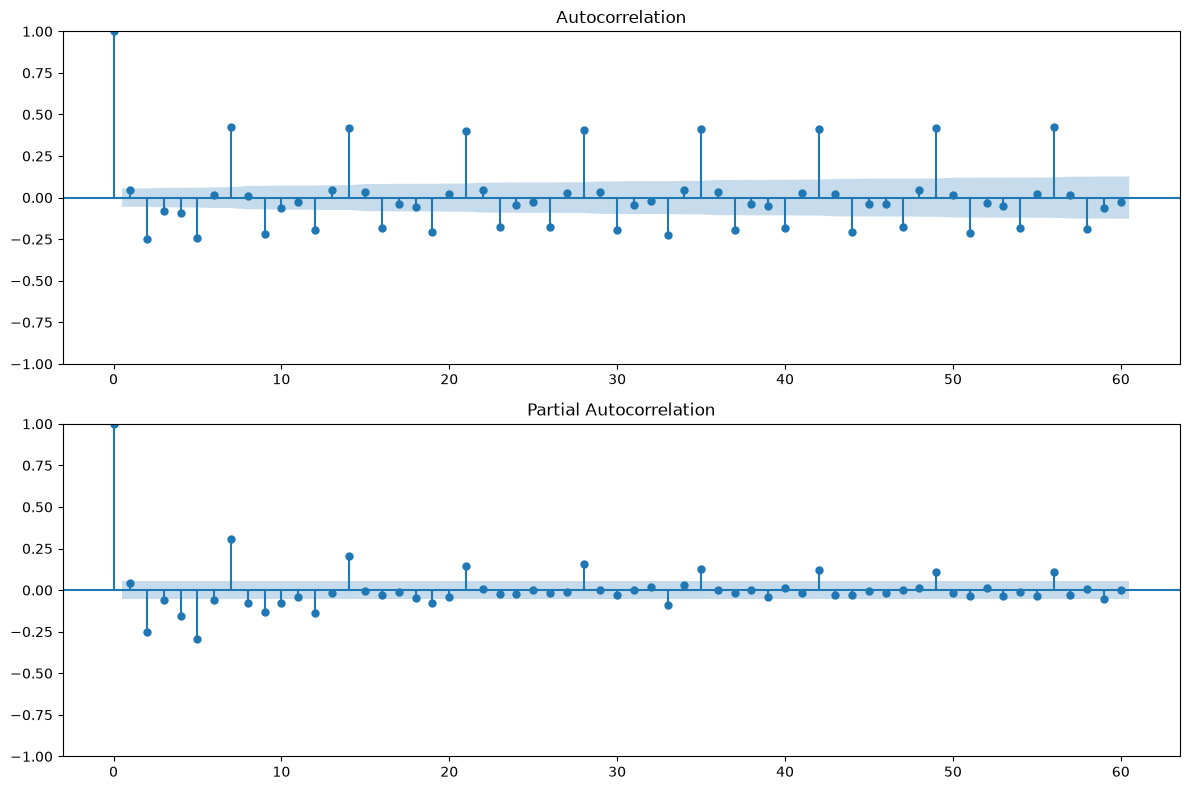

In [27]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(difference(demand_data,1), ax=ax[0], lags=60)   # ~2 months of days
plot_pacf(difference(demand_data,1), ax=ax[1], lags=60)

plt.tight_layout()
plt.show()

### SARIMAX Model

In [33]:
# ---- Split: dev for selection + walk-forward, final tail untouched for reporting ----
final_holdout = 90
dev = demand_data.iloc[:-final_holdout]
test_final = demand_data.iloc[-final_holdout:]

# Within dev, a train/test for the grid search's RMSE ranking
split = int(len(dev) * 0.80)
train = dev.iloc[:split]
test  = dev.iloc[split:]

def sarima_grid_search(train, test, m=7, p=range(2), d=range(2), q=range(2), P=range(2), D=range(2), Q=range(2)):
    """
    Grid search SARIMA orders, fixing d=1 and D=1 (known from the trend/seasonal
    decomposition). Models are ranked by forecast RMSE on the test set, with
    coefficient significance reported as a diagnostic rather than a sort key.
    """
    rows = []

    with (warnings.catch_warnings()):
        warnings.simplefilter("ignore")
        for pp, dd, qq, PP, DD, QQ in itertools.product(p,d, q, P, D, Q):
            order = (pp, dd, qq)
            seasonal_order = (PP, DD, QQ, m)
            try:
                fit = SARIMAX(train,
                              order=order,
                              seasonal_order=seasonal_order
                              ).fit(disp=False, maxiter=200)
                rmse = np.sqrt(mean_squared_error(test, fit.forecast(len(test))))
                pvals = fit.pvalues.drop('sigma2', errors='ignore')
                rows.append({
                    'order': order,
                    'seasonal_order': seasonal_order,
                    'RMSE': rmse,
                    'AIC': fit.aic,
                    'all_significant': bool((pvals < 0.05).all()),
                })
            except Exception:
                continue

    return pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)

# Search
results = sarima_grid_search(train, test)
print(results.head(10))


       order seasonal_order          RMSE           AIC  all_significant
0  (0, 1, 1)   (1, 0, 1, 7)  11205.116948  18222.197354             True
1  (0, 1, 0)   (1, 1, 1, 7)  11468.639302  18247.732747             True
2  (0, 1, 0)   (1, 0, 1, 7)  14951.322940  18225.152609             True
3  (1, 1, 0)   (1, 0, 1, 7)  16461.562431  18271.748061             True
4  (1, 1, 1)   (1, 0, 1, 7)  16521.607025  18273.991445            False
5  (1, 0, 0)   (1, 0, 1, 7)  21324.988830  18053.759827             True
6  (1, 0, 1)   (1, 1, 1, 7)  22690.479809  18836.579864             True
7  (1, 0, 0)   (1, 1, 1, 7)  22729.745659  18831.031259             True
8  (1, 0, 1)   (0, 1, 1, 7)  22885.299563  18846.093581             True
9  (1, 0, 0)   (0, 1, 1, 7)  22891.386002  18838.855714             True


In [34]:
candidates = list(zip(results['order'].head(5), results['seasonal_order'].head(5)))

def walk_forward(series, order, seasonal_order, initial=600, horizon=7):
    preds, actuals, idx = [], [], []
    start, n = initial, len(series)
    while start + horizon <= n:
        tr    = series.iloc[:start]
        truth = series.iloc[start:start + horizon]
        try:
            fit = SARIMAX(tr, order=order, seasonal_order=seasonal_order,
                          enforce_stationarity=False, enforce_invertibility=False
                          ).fit(disp=False, maxiter=50)
            preds.extend(fit.forecast(horizon).values)
            actuals.extend(truth.values)
            idx.extend(truth.index)
        except Exception:
            pass
        start += horizon
    preds, actuals = np.array(preds), np.array(actuals)
    return {
        'MAE':  mean_absolute_error(actuals, preds),
        'RMSE': np.sqrt(mean_squared_error(actuals, preds)),
        'MAPE': np.mean(np.abs((actuals - preds) / actuals)) * 100,
        'n_folds': len(preds) // horizon,
        'index': idx, 'preds': preds, 'actuals': actuals,
    }

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for order, seas in candidates:
        wf = walk_forward(dev, order, seas)
        print(f"{order}x{seas}  WF-RMSE: {wf['RMSE']:,.0f}  MAE: {wf['MAE']:,.0f}  MAPE: {wf['MAPE']:.2f}%")

(0, 1, 1)x(1, 0, 1, 7)  WF-RMSE: 8,424  MAE: 6,093  MAPE: 2.43%
(0, 1, 0)x(1, 1, 1, 7)  WF-RMSE: 8,548  MAE: 6,242  MAPE: 2.49%
(0, 1, 0)x(1, 0, 1, 7)  WF-RMSE: 8,423  MAE: 6,096  MAPE: 2.44%
(1, 1, 0)x(1, 0, 1, 7)  WF-RMSE: 8,428  MAE: 6,096  MAPE: 2.44%
(1, 1, 1)x(1, 0, 1, 7)  WF-RMSE: 8,418  MAE: 6,087  MAPE: 2.43%


### Conclusion
This SARIMAX model can only capture one seasonal period at a time, that is, it cannot simultaneously model the daily, weekly, and annual cycles present in the AIL data.
Not good for a long term horizon